# Liver Patient Dataset

In [ ]:
# imports
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Read in the data

In [ ]:
# Download latest version
path = kagglehub.dataset_download("shauryasrivastava01/liver-patient-dataset")

print("Path to dataset files:", path)
# List files in the downloaded dataset directory
print(os.listdir(path))

Using Colab cache for faster access to the 'liver-patient-dataset' dataset.
Path to dataset files: /kaggle/input/liver-patient-dataset
['liver_patient_dataset.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "liver_patient_dataset.csv"))
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,Liver Disease
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,Liver Disease
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,Liver Disease
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,Liver Disease
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,Liver Disease


In [ ]:
# replace the target variable with 1 for positive class (liver disease) and 0 for negative class (no liver disease)
df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})

/tmp/ipykernel_2808/1458033854.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Selector'] = df['Selector'].replace({'Liver Disease':1, 'No Liver Disease':0})


In [ ]:
# change the name of the selector column to target
df.rename(columns={'Selector':'Target'}, inplace=True)
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
# calculate the prevalance
prevalance = np.mean(df.Target) * 100
print(f'The prevalance is {prevalance:.2f}%')

The prevalance is 71.36%


In [ ]:
# check for null values
print(df.isna().sum())

Age          0
Gender       0
TB           0
DB           0
Alkphos      0
Sgpt         0
Sgot         0
TP           0
ALB          0
A/G Ratio    0
Target       0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        583 non-null    int64  
 1   Gender     583 non-null    object 
 2   TB         583 non-null    float64
 3   DB         583 non-null    float64
 4   Alkphos    583 non-null    int64  
 5   Sgpt       583 non-null    int64  
 6   Sgot       583 non-null    int64  
 7   TP         583 non-null    float64
 8   ALB        583 non-null    float64
 9   A/G Ratio  583 non-null    float64
 10  Target     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [ ]:
# print the summary statistics of the numeric data
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


From looking at the summary statistics, TB, DB, Alkphos, Sgpt and Sgot all need to be transformed so they have a more normal distribution. They are all clearly very skewed, as they have standard deviations that are much greater than the means and have max values that are much higher than the number that's the 75th percentile of the column. These are all skewed to the right so we will use log transformations on the columns.

In [ ]:
to_transform = ['TB',	'DB',	'Alkphos',	'Sgpt',	'Sgot']
names = ['TB_log',	'DB_log',	'Alkphos_log',	'Sgpt_log',	'Sgot_log']
df[names] = np.log(df[to_transform])
df.head()

,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,TB_log,DB_log,Alkphos_log,Sgpt_log,Sgot_log
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1,-0.356675,-2.302585,5.231109,2.772589,2.890372
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1,2.388763,1.704748,6.549651,4.158883,4.605170
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1,1.987874,1.410987,6.194405,4.094345,4.219508
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1,0.000000,-0.916291,5.204007,2.639057,2.995732
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1,1.360977,0.693147,5.273000,3.295837,4.077537


In [ ]:
df.describe()

,Age,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Target,TB_log,DB_log,Alkphos_log,Sgpt_log,Sgot_log
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551,0.463421,-0.650373,5.493417,3.751829,3.956771
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490,1.018527,1.326394,0.528128,0.900236,0.997381
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000,-0.916291,-2.302585,4.143135,2.302585,2.302585
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000,-0.223144,-1.609438,5.167635,3.135494,3.218876
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000,0.000000,-1.203973,5.337538,3.555348,3.737670
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000,0.955511,0.262364,5.697093,4.102609,4.465908
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000,4.317488,2.980619,7.654443,7.600902,8.502891


### Question and background information on the data and why you are asking this question(s). Couple of paragraphs.

### Our Question:

How accurately can we predict whether a patient has liver disease using clinical biomarkers, and which features are most strongly associated with the presence of the disease?



### Background Information:

Liver disease is an increasing global health concern, influenced by factors such as alcohol consumption, chronic hepatitis infections, and obesity. The detection of liver disease in its early stages is critical, as conditions progress silently and significantly in advanced stages. To assess liver function, clinical biomarkers such as bilirubin levels, liver enzymes, and protein concentrations are used in medical settings, though the interpretation of these biomarkers can be complex. Their unique relationships with the presence of liver disease may also not be immediately identifiable without further analysis, which is what our question aims to address.

For this project, we used a Kaggle dataset of liver disease patient records from the northeast region of Andhra Pradesh, India. This dataset includes demographic information, such as age and gender, along with various biomarkers related to liver function. The dataset is intentionally suited for machine learning and classification tasks, equipped with labeled outcomes indicating whether or not each patient has the disease. Our aim is to explore how data-driven methods can support medical diagnosis while considering the variability in biomarker levels and potential differences across individuals.

In order to find an answer to our central question, we will apply machine learning methods to evalute the relationship between biomarkers and disease status, implementing models of Logistic Regression and Decision Trees. We intend on evaluting both predictive performance and the most informative variables, providing insight into which clinical measurements are most indictive of liver disease. This will be assessed using a variety of performance metrics that will reveal which model best serves our purpose. Overall, we want to be able to connect our findings back to real-world medical relevance, ultimately contributing to liver disease research.

### Exploratory Data Analysis – Initial summary statistics and graphs with an emphasis on variables you believe to be important for your analysis. Don’t just show a bunch of graphs, you need a story.

### 1. Dataset Overview and Class Distribution

First, we want to examine the overall structure of the dataset and the distribution of the target variable: the presence of liver disease. 0 represents the negative class, and 1 represents the positive class. We see in the data cleaning process that this dataset contains 583 patient records with no missing values, making it already suitable for analysis.

One of our key initial findings is the clear class imbalance in the target variable. The prevelance reveals that approximately 71% of patients are in the positive class, meaning they have liver disease, while 29% are not. This imbalance is important to note as a possible limitation, as it may bias our models toward predicting the majority class, so this must be considered during model evaluation.

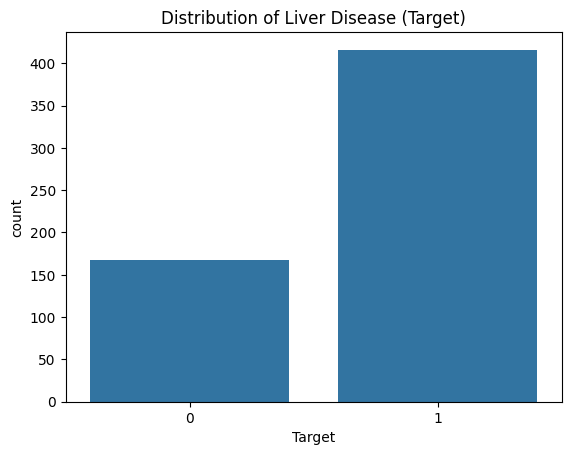

In [ ]:
sns.countplot(x='Target', data=df)
plt.title("Distribution of Liver Disease (Target)")
plt.show()

This distribution suggests that liver disease is highly prevalent in the dataset. As a result, accuracy alone may not be a sufficient evaluation metric, since a model could achieve high accuracy by simply predicting the majority class.

### 2. Distribution of Key Biomarkers

Our initial summary statistics revealed that several clinical biomarkers are heavily right-skewed with extreme outliers, particularly TB, DB, Alkphos, Sgpt, and Sgot. This is not unusual in medical data, where abnormal biomarker levels can face a significant increase in diseased patients. In order to address this, we applied log transformations on these variables to make comparisons across the data much clearer. This compresses extreme values, making the distributions more symmetric and interpretations more obvious.

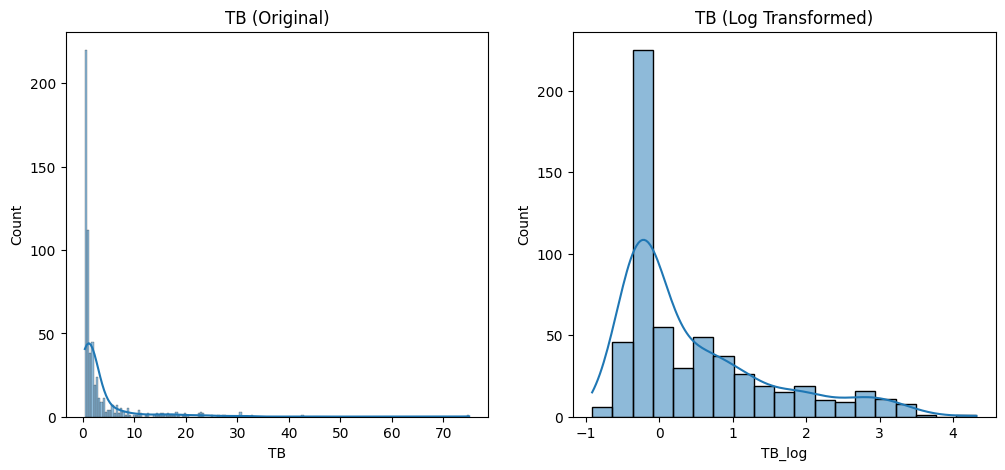

In [ ]:
# Example of visual log transformation: TB

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['TB'], ax=axes[0], kde=True)
axes[0].set_title("TB (Original)")

sns.histplot(df['TB_log'], ax=axes[1], kde=True)
axes[1].set_title("TB (Log Transformed)")

plt.show()

The log transformation reduces skewness and stabilizes variance, making these variables more suitable for our Logistic Regression and Decision tree models, which typically assume more normally distributed input data.

### 3. Biomarkers vs Liver Disease

Since we primarily want to understand which variables are most informative, we must compare biomarker distributions in the context of patients with and without liver disease.

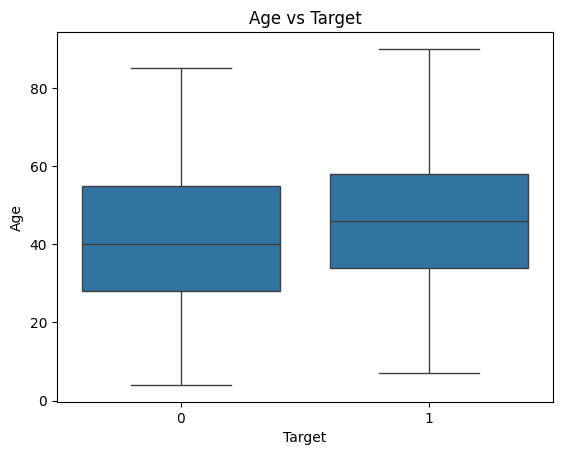

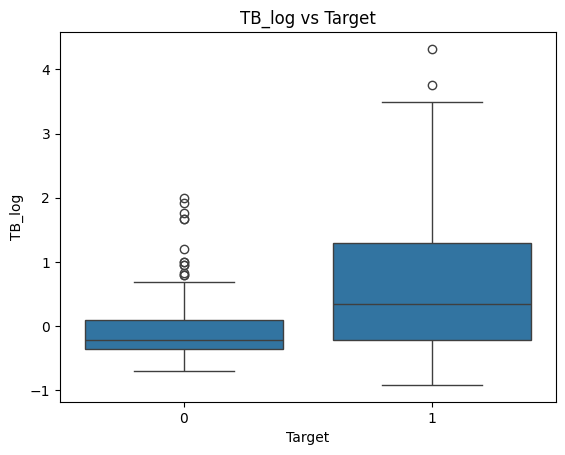

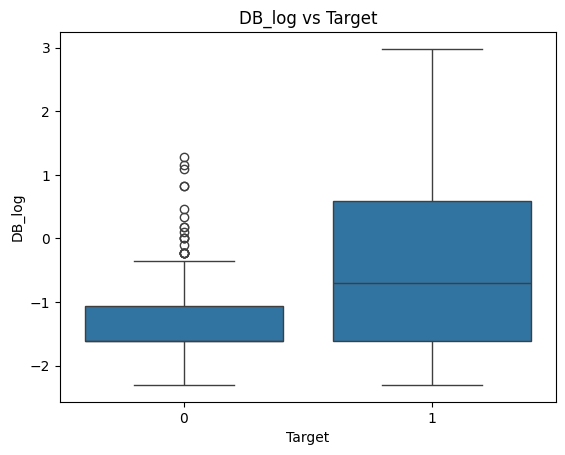

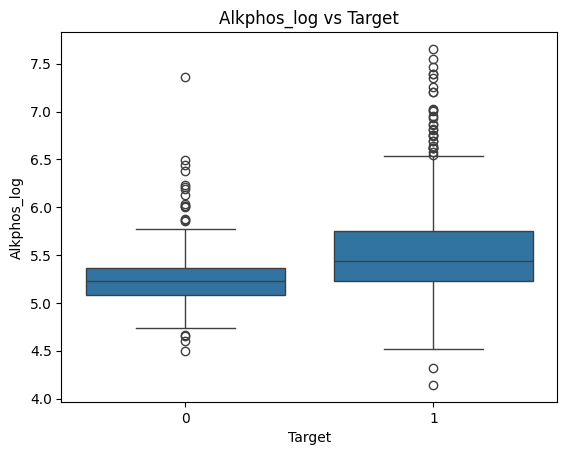

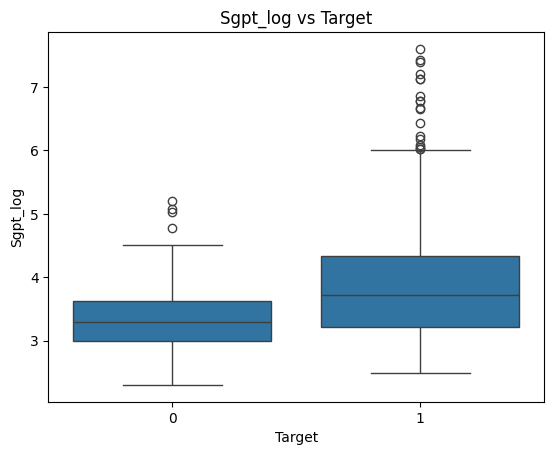

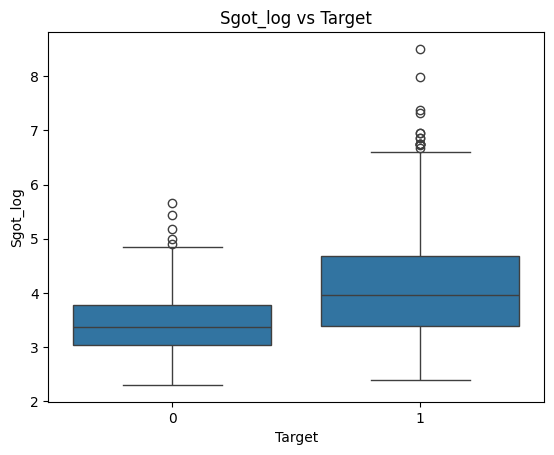

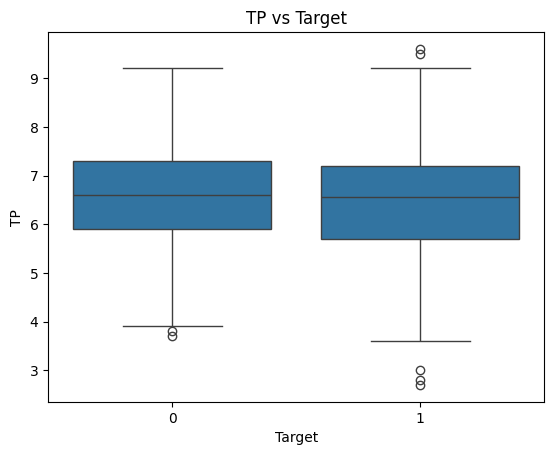

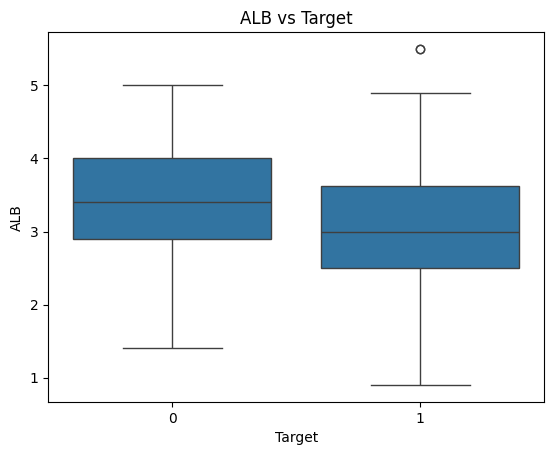

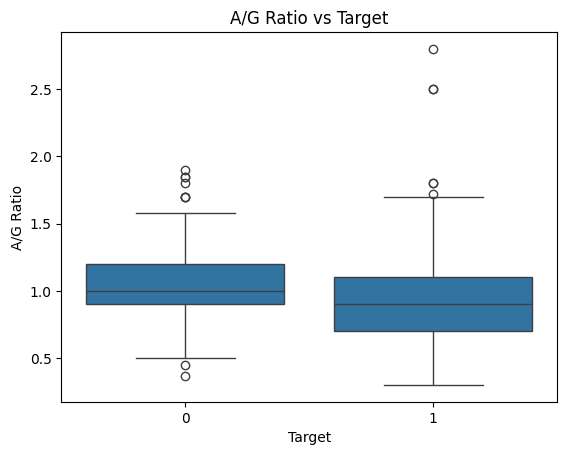

In [ ]:
features = ['Age', 'TB_log', 'DB_log', 'Alkphos_log', 'Sgpt_log', 'Sgot_log', 'TP', 'ALB', 'A/G Ratio']

for col in features:
    sns.boxplot(x='Target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

The boxplots reveal that patients with liver disease consistently show higher levels of bilirubin and liver enzymes compared to those without. The separation between the two groups is especially noticeable for variables like Sgpt and Sgot, which suggests that these may be strong predictors in our models.

### 4. Correlation Analysis

Next, we directly examine relationships between variables using a correlation matrix to identify redundancy and potential multicollinearity.

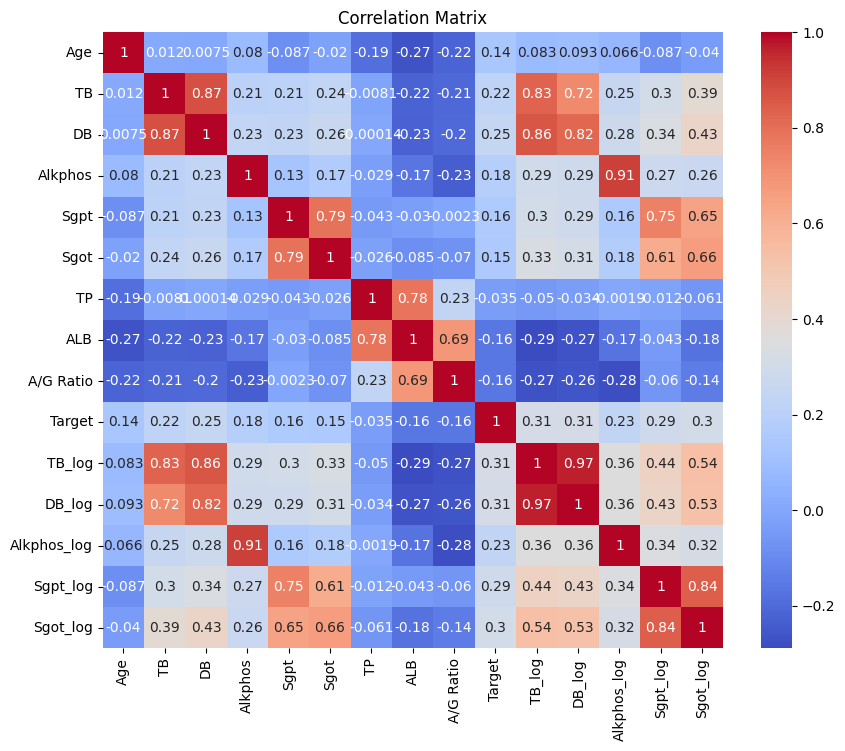

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix reveals that several biomarkers are moderately to strongly correlated (Sgpt and Sgot, TB and DB), which is expected since they measure similar aspects of liver function. Sgpt and Sgot are both enzymes found in the liver, and bilirubin is a substance produced when red blood cells are broken down. This suggests that some variables may provide overlapping information, meaning not all features will contribute their own unique value to the model.

On the other hand, most features are evidently only moderately correlated with the target, meaning liver disease is more likely to be influenced by a combination of biomarkers rather than a single specific variable.

### 5. Demographic Insights

We also want to get a general idea of potentially beneficial demographic insights, which includes the variables age and gender.

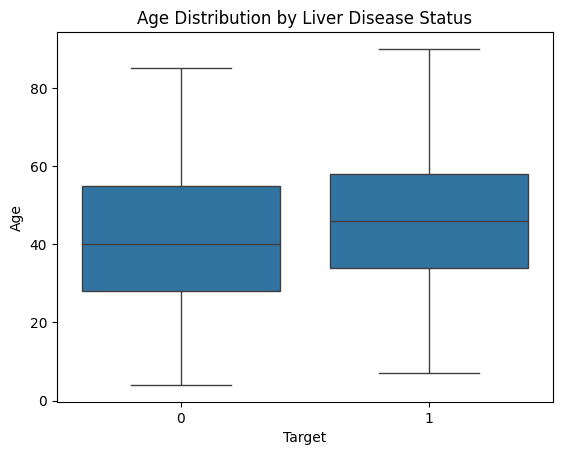

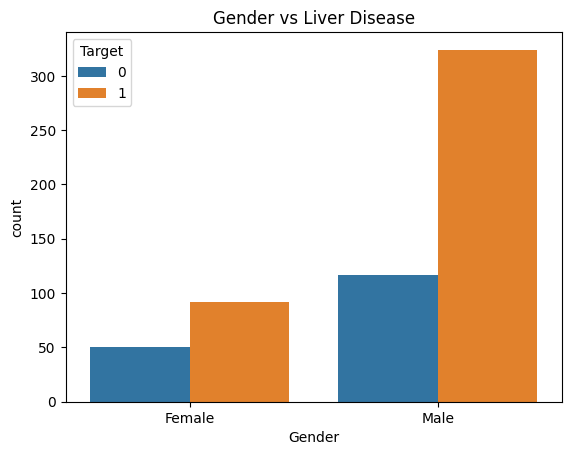

In [ ]:
sns.boxplot(x='Target', y='Age', data=df)
plt.title("Age Distribution by Liver Disease Status")
plt.show()

sns.countplot(x='Gender', hue='Target', data=df)
plt.title("Gender vs Liver Disease")
plt.show()

We see that age may show a slight trend where older individuals are more likely to have liver disease, though some overlap exists.

We also see that the dataset is predominantly male at about 76%, which may introduce bias. Liver disease appears much more common among males in the dataset, but this may simply be a reflection of skewed sampling rather than a true population effect.

### 6. Key EDA Takeaways

This exploratory data analysis highlights several important patterns in the dataset. Liver disease is highly prevalent, resulting in class imbalance that must be accounted for in modeling. Certain biochemical markers, including total bilirubin (TB), direct bilirubin (DB), alkaline phosphatase (Alkphos), and liver enzymes (Sgpt and Sgot), are heavily right-skewed and required log transformation to improve distributions. The correlation analysis revealed strong relationships among a select few biomarkers, particularly TB & DB and Sgpt & Sgot, but much weaker relationships among the rest. No single variable is highly predictive of liver disease on its own, as most remain moderately positively correlated with the target. Demographic variables of age and gender show relatively weak relationships.

Overall, these findings suggest our modeling process will benefit from combining multiple biochemical markers to predict liver disease, placing particular emphasis on bilirubin levels and liver enzymes as the most informative.